In [1]:
# imports
import copy
import collections.abc
import gpytorch
import gpytorch.constraints
import IPython.display
import matplotlib.axes
import matplotlib.colors
import matplotlib.cm
import matplotlib.figure
import matplotlib.pyplot as plt
import matplotlib.ticker
import numpy as np
import numpy.typing as npt
import scipy.spatial
import sklearn.exceptions
import sklearn.gaussian_process
import torch
import typing
import warnings

torch.set_default_dtype(torch.float64)
warnings.filterwarnings("ignore", category=sklearn.exceptions.ConvergenceWarning)

In [2]:
# constants
FIGSIZE: tuple[float, float] = (6.4, 4.8)
N_GAUSS: typing.Literal[10] = 10
DIM: typing.Literal[2] = 2
MIN: float = -10.0
MAX: float = 10.0
N_GRIDS: typing.Literal[101] = 101
NOISE: float = 1e-4
COLOR_RATIO: float = 1.1
X1: npt.NDArray[np.double] = np.linspace(MIN, MAX, N_GRIDS, dtype=np.double)
X2: npt.NDArray[np.double] = np.linspace(MIN, MAX, N_GRIDS, dtype=np.double)
x1, x2 = np.meshgrid(X1, X2)
x_test: npt.NDArray[np.double] = np.concatenate((x1[..., np.newaxis], x2[..., np.newaxis]), axis=-1).reshape(-1, DIM)

Centers are at
 [[-0.13784624 -1.42335884]
 [-3.18522203  0.3025866 ]
 [-3.32513723  0.07231185]
 [ 0.04157721  0.06815559]
 [ 0.6586191   1.22882759]
 [ 0.57919715 -1.62091014]
 [-2.52363542  1.47067596]
 [ 3.14999495 -2.68495403]
 [ 1.49995336  1.41268589]
 [-0.74702739 -1.07789524]]
Widths are
 [[1.84939891 1.02441368]
 [1.38136716 1.55955841]
 [1.15430184 0.6147162 ]
 [1.02368651 1.23166216]
 [1.36985871 1.27755855]
 [0.52257349 1.16347141]
 [0.76288478 0.29228807]
 [1.21735839 0.12857451]
 [1.16604059 1.72441376]
 [1.34056059 0.61966067]]
Weights of Gaussian are
 [-0.46004497  0.62836011 -0.62694375  0.84249225  0.16204339 -0.73258005
 -0.75438581  0.91099714  0.4535161  -0.91552513]


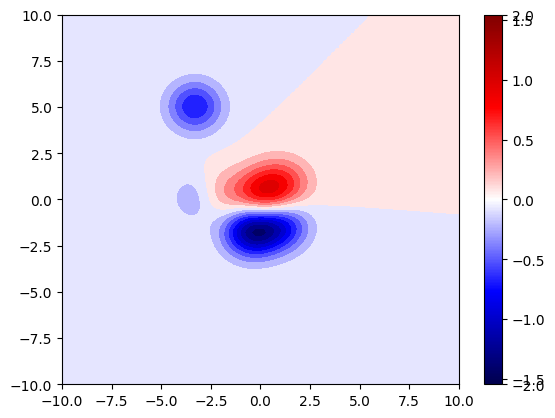

In [3]:
# distribution
rng: np.random.Generator = np.random.Generator(np.random.MT19937(0))
CENTER: npt.NDArray[np.double] = rng.uniform(MIN / 3.0, MAX / 3.0, (N_GAUSS, DIM))
WIDTH: npt.NDArray[np.double] = rng.uniform(0.1, 2.0, (N_GAUSS, DIM))
WEIGHT: npt.NDArray[np.double] = rng.uniform(-1.0, 1.0, N_GAUSS)
print("Centers are at\n", CENTER, sep=None)
print("Widths are\n",WIDTH, sep=None)
print("Weights of Gaussian are\n", WEIGHT, sep=None)


def dist_func(x: npt.NDArray[np.double]) -> npt.NDArray[np.double]:
	if x.ndim == 1:
		x = x[:, np.newaxis]
	return np.sum(WEIGHT * np.exp(-np.sum(np.square(x[:, np.newaxis, :] - CENTER / WIDTH), axis=-1) / 2.0), axis=-1)


y_test: npt.NDArray[np.double] = np.reshape(dist_func(x_test), (N_GRIDS, N_GRIDS))
LIMIT: float = COLOR_RATIO * np.max(np.abs(y_test))
CMAP: str = 'seismic'
LOCATOR: matplotlib.ticker.MaxNLocator = matplotlib.ticker.MaxNLocator(nbins=21)
NORM: matplotlib.colors.CenteredNorm = matplotlib.colors.CenteredNorm(0.0, LIMIT, True)
fig: matplotlib.figure.Figure = plt.figure(figsize=FIGSIZE)
ax: matplotlib.axes.Axes = fig.subplots()
fig.colorbar(matplotlib.cm.ScalarMappable(cmap=CMAP, norm=NORM), ax=ax)
ax.contourf(x1, x2, y_test, cmap=CMAP, norm=NORM, vmin=-LIMIT, vmax=LIMIT, locator=LOCATOR)

Step size for random walk is 7.037744796743215
Number of steps for random walk is 1000
Acceptance ratio for central points is within [0.136, 0.215]
Acceptance ratio for extra points is within [0.311, 0.417]


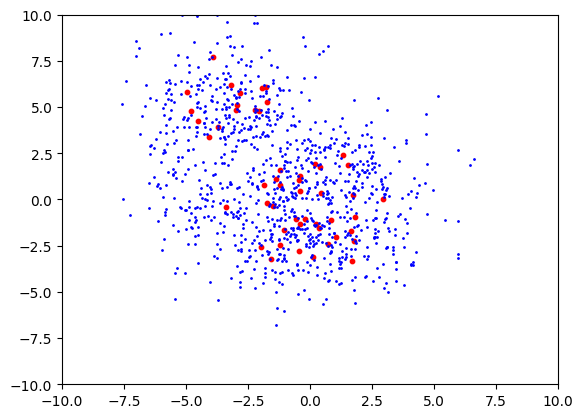

In [4]:
# sample points
rng = np.random.Generator(np.random.MT19937(0))
plt.close(fig)


def random_walk() -> tuple[npt.NDArray[np.double], npt.NDArray[np.double], npt.NDArray[np.double], npt.NDArray[np.double]]:
	PTS_RATIO: typing.Literal[5] = 5
	EXTRA_RATIO: typing.Literal[20] = 20
	STEP_SIZE: float = np.sqrt(np.max(scipy.spatial.distance.pdist(CENTER, 'sqeuclidean')))
	NUM_STEP: typing.Literal[1000] = 1000
	print("Step size for random walk is {}".format(STEP_SIZE))
	print("Number of steps for random walk is {}".format(NUM_STEP))
	central_pts: npt.NDArray[np.double] = np.repeat(CENTER, PTS_RATIO, axis=0)
	weights: npt.NDArray[np.double] = dist_func(central_pts)
	acc_ratio: npt.NDArray[np.double] = np.zeros(weights.shape)
	for i in range(NUM_STEP):
		new_pts: npt.NDArray[np.double] = central_pts + rng.uniform(-STEP_SIZE, STEP_SIZE, central_pts.shape)
		new_pts = np.maximum(new_pts, MIN)
		new_pts = np.minimum(new_pts, MAX)
		new_weights: npt.NDArray[np.double] = dist_func(new_pts)
		acc: npt.NDArray[np.bool_] = np.abs(new_weights / weights) > rng.uniform(0, 1, weights.shape)
		acc_ratio += acc
		central_pts = np.where(acc[:, np.newaxis], new_pts, central_pts)
		weights = np.where(acc, new_weights, weights)
	acc_ratio /= NUM_STEP
	print("Acceptance ratio for central points is within [{}, {}]".format(np.min(acc_ratio), np.max(acc_ratio)))
	extra_pts: npt.NDArray[np.double] = np.repeat(central_pts, EXTRA_RATIO, axis=0)
	extra_weights: npt.NDArray = dist_func(extra_pts)
	acc_ratio: npt.NDArray[np.double] = np.zeros(extra_weights.shape)
	for _ in range(NUM_STEP):
		new_pts = extra_pts + rng.uniform(-STEP_SIZE, STEP_SIZE, extra_pts.shape)
		new_pts = np.maximum(new_pts, MIN)
		new_pts = np.minimum(new_pts, MAX)
		new_weights: npt.NDArray[np.double] = dist_func(new_pts)
		acc: npt.NDArray[np.bool_] = np.power(np.abs(new_weights / extra_weights), 0.3) > rng.uniform(0, 1, extra_weights.shape)
		acc_ratio += acc
		extra_pts = np.where(acc[:, np.newaxis], new_pts, extra_pts)
		extra_weights = np.where(acc, new_weights, extra_weights)
	acc_ratio /= NUM_STEP
	print("Acceptance ratio for extra points is within [{}, {}]".format(np.min(acc_ratio), np.max(acc_ratio)))
	return central_pts, weights, extra_pts, extra_weights


x, y, extra_x, extra_y = random_walk()
x_all: npt.NDArray[np.double] = np.concatenate((x, extra_x))
y_all: npt.NDArray[np.double] = np.concatenate((y, extra_y))
fig: matplotlib.figure.Figure = plt.figure(figsize=FIGSIZE)
ax: matplotlib.axes.Axes = fig.subplots()
ax.set_xlim(MIN, MAX)
ax.set_ylim(MIN, MAX)
ax.scatter(x[:, 0], x[:, 1], 10, 'red')
ax.scatter(extra_x[:, 0], extra_x[:, 1], 1, 'blue')

In [5]:
x_t: torch.Tensor = torch.from_numpy(x)
y_t: torch.Tensor = torch.from_numpy(y)
extra_x_t: torch.Tensor = torch.from_numpy(extra_x)
extra_y_t: torch.Tensor = torch.from_numpy(extra_y)
x_all_t: torch.Tensor = torch.from_numpy(x_all)
y_all_t: torch.Tensor = torch.from_numpy(y_all)
x_test_t: torch.Tensor = torch.from_numpy(x_test)
y_test_t: torch.Tensor = torch.from_numpy(y_test)

In [6]:
def plot(pred: npt.NDArray[np.double]) -> None:
	diff: npt.NDArray[np.double] = pred - y_test
	color_limit: float = COLOR_RATIO * np.max(np.abs(diff))
	print("Mean squared error =", np.average(diff ** 2))
	print("Mean absolute error =", np.average(np.abs(diff)))
	print("Maximum error =", np.max(np.abs(diff)))
	fig: matplotlib.figure.Figure = plt.figure(figsize=(FIGSIZE[0] * 2, FIGSIZE[1]))
	axs = fig.subplots(nrows=1, ncols=2)
	fig.colorbar(matplotlib.cm.ScalarMappable(cmap=CMAP, norm=NORM), ax=axs[0])
	axs[0].contourf(x1, x2, pred, cmap=CMAP, norm=NORM, vmin=-LIMIT, vmax=LIMIT, locator=LOCATOR)
	norm: matplotlib.colors.CenteredNorm = matplotlib.colors.CenteredNorm(0.0, color_limit, True)
	fig.colorbar(matplotlib.cm.ScalarMappable(cmap=CMAP, norm=norm), ax=axs[1])
	axs[1].contourf(x1, x2, diff, cmap=CMAP, norm=norm, vmin=-color_limit, vmax=color_limit, locator=LOCATOR)

sklearn GPR using RBF kernel with noise
Kernel:

0.406**2 * RBF(length_scale=[1.6, 1.27]) + WhiteKernel(noise_level=0.0001)

Mean squared error = 0.001767669788752133
Mean absolute error = 0.01909922095827347
Maximum error = 0.26937113903250715


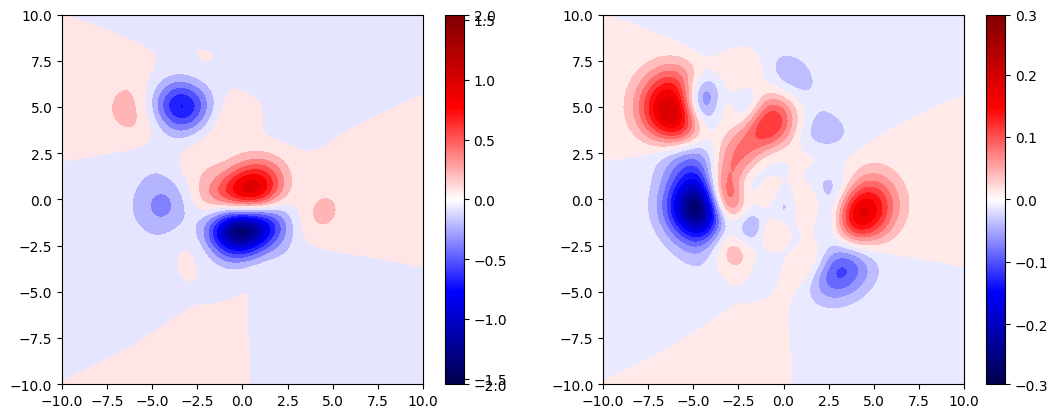

In [7]:
# sklearn gpr using rbf kernel
plt.close(fig)
print("sklearn GPR using RBF kernel with noise")


def sklearn_rbf_gpr(x: npt.NDArray[np.double], y: npt.NDArray[np.double], x_test: npt.NDArray[np.double]) -> npt.NDArray[np.double]:
	gpr: sklearn.gaussian_process.GaussianProcessRegressor = sklearn.gaussian_process.GaussianProcessRegressor(
		1.0 * sklearn.gaussian_process.kernels.RBF(np.ones((DIM))) + sklearn.gaussian_process.kernels.WhiteKernel(NOISE, (NOISE, NOISE))
	).fit(x, y)
	print('Kernel:', end='')
	IPython.display.display(gpr.kernel_)
	return gpr.predict(x_test).reshape(N_GRIDS, N_GRIDS)


plot(sklearn_rbf_gpr(x, y, x_test))

In [8]:
class MyGPR(gpytorch.models.ExactGP):
	def __init__(self, x: torch.Tensor, y: torch.Tensor, likelihood: gpytorch.likelihoods.Likelihood, kernel: gpytorch.kernels.Kernel):
		super().__init__(x, y, likelihood)
		self.mean: gpytorch.means.Mean = gpytorch.means.ZeroMean()
		self.cov: gpytorch.kernels.Kernel = kernel

	def forward(self, x: torch.Tensor) -> gpytorch.distributions.MultivariateNormal:
		return gpytorch.distributions.MultivariateNormal(self.mean(x), self.cov(x))


def gpytorch_gpr(
	x: torch.Tensor,
	y: torch.Tensor,
	kernel: gpytorch.kernels.Kernel,
	loss_func: typing.Callable,
	x_test: torch.Tensor,
	predictor: typing.Callable | None = None,
	**kwargs
) -> npt.NDArray[np.double]:
	MAX_ITER: typing.Literal[50000] = 50000
	FTOL: float = 2.2204460492503131e-09
	GTOL: float = 1e-5
	def print_model(model: gpytorch.models.ExactGP, print_grad: bool = False) -> None:
		def print_tensor(t: torch.Tensor):
			if t.dim() == 0 or np.prod(t.size()) == 1:
				return t.item()
			else:
				return t.detach().numpy()

		fmt: str = 'Parameter name: {0:42} value = {1}'
		fmt_grad: str = fmt + ' grad = {2}'
		for param_name, param, constraint in model.named_parameters_and_constraints():
			if print_grad and param.grad is not None:
				print(fmt_grad.format(param_name, print_tensor(param), print_tensor(param.grad)))
			else:
				print(fmt.format(''.join(param_name.split('raw_')), print_tensor(constraint.transform(param))))

	def get_lr(optimizer: torch.optim.Optimizer) -> float:
		return optimizer.param_groups[0]['lr']

	torch.manual_seed(0)
	# train model
	likelihood: gpytorch.likelihoods.FixedNoiseGaussianLikelihood = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(torch.full((x.shape[0],), NOISE))
	model: MyGPR = MyGPR(x, y, likelihood, kernel)
	model.train()
	likelihood.train()
	print_model(model)
	last_value: float = np.inf
	finish_early: bool = False
	optimizer: torch.optim.Optimizer = torch.optim.Rprop(model.parameters(), lr=1.0)
	optimizer.zero_grad()
	loss: torch.Tensor = loss_func(x, y, model, likelihood, **kwargs)
	loss.backward()
	for i in range(MAX_ITER):
		# adjust lr
		old_prm: dict[str, torch.Tensor] = copy.deepcopy(model.state_dict())
		optimizer.step()
		loss = loss_func(x, y, model, likelihood, **kwargs)
		lr_divided: bool = False
		while loss >= last_value:
			lr_divided = True
			model.load_state_dict(old_prm)
			optimizer = optimizer.__class__(model.parameters(), lr=get_lr(optimizer) / 2.0)
			optimizer.step()
			loss = loss_func(x, y, model, likelihood, **kwargs)
		if i % (MAX_ITER // 10) == 0:
			print('Iter {} - Loss: {} - lr: {}'.format(i, loss.item(), get_lr(optimizer)))
			print_model(model, True)
			print_model(model)
		# stopping criteria
		if (last_value - loss.item()) / max(abs(last_value), abs(loss.item()), 1.0) < FTOL:
			finish_early = True
			print("Convergence: |f_i - f_{i+1}| <= FTOL")
			print('Iter {} - Loss: {} - lr: {}'.format(i, loss.item(), get_lr(optimizer)))
			break
		if np.sqrt(sum([torch.sum(param.grad ** 2).item() for param in model.parameters()])) < GTOL:
			finish_early = True
			print("Convergence: |Gradient| <= GTOL")
			print('Iter {} - Loss: {} - lr: {}'.format(i, loss.item(), get_lr(optimizer)))
			break
		last_value = loss.item()
		optimizer =  optimizer.__class__(model.parameters(), lr=get_lr(optimizer) * (1.0 if lr_divided else 2.0))
		optimizer.zero_grad()
		loss = loss_func(x, y, model, likelihood, **kwargs)
		loss.backward()
	if not finish_early:
		print('Iter {} - Loss: {} - lr: {}'.format(MAX_ITER, last_value, [param['lr'] for param in optimizer.param_groups]))
		print("Stop: Total No. iterations reached limit.")
	print_model(model)
	# predict
	model.eval()
	likelihood.eval()
	if predictor is None:
		return likelihood(model(x_test), noise=torch.full((x_test.shape[0],), NOISE)).mean.detach().numpy().reshape(N_GRIDS, N_GRIDS)
	else:
		return predictor(model, likelihood, x, x_test, **kwargs).detach().numpy().reshape(N_GRIDS, N_GRIDS)

gpytorch GPR using RBF kernel with exact mll
Parameter name: cov.outputscale                            value = 0.6931471805599453
Parameter name: cov.base_kernel.lengthscale                value = [[0.69314718 0.69314718]]
Iter 0 - Loss: -0.8580396291319038 - lr: 1.0
Parameter name: cov.raw_outputscale                        value = -1.0 grad = 0.3050734162884946
Parameter name: cov.base_kernel.raw_lengthscale            value = [[1. 1.]] grad = [[-0.36841046 -0.37932829]]
Parameter name: cov.outputscale                            value = 0.31326168751822286
Parameter name: cov.base_kernel.lengthscale                value = [[1.31326169 1.31326169]]
Convergence: |f_i - f_{i+1}| <= FTOL
Iter 54 - Loss: -1.0320006020347232 - lr: 6.103515625e-05
Parameter name: cov.outputscale                            value = 0.16510763616649332
Parameter name: cov.base_kernel.lengthscale                value = [[1.60182571 1.27072285]]
Mean squared error = 0.0017676294303385711
Mean absolute error = 0

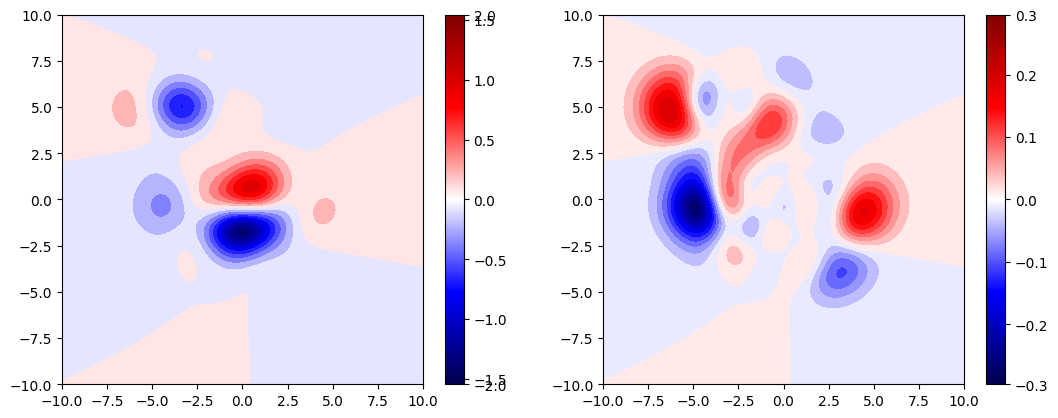

In [9]:
plt.close(fig)
print("gpytorch GPR using RBF kernel with exact mll")


def exact_mll(
	x: torch.Tensor,
	y: torch.Tensor,
	model: gpytorch.models.ExactGP,
	likelihood: gpytorch.likelihoods.GaussianLikelihood
) -> torch.Tensor:
	return -gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)(model(x), y)


plot(gpytorch_gpr(x_t, y_t, gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(DIM)), exact_mll, x_test_t))

gpytorch GPR using RBF kernel with loocv pseudo mll
Parameter name: cov.outputscale                            value = 0.6931471805599453
Parameter name: cov.base_kernel.lengthscale                value = [[0.69314718 0.69314718]]
Iter 0 - Loss: -2.081962975705929 - lr: 1.0
Parameter name: cov.raw_outputscale                        value = -1.0 grad = 0.34891802579616554
Parameter name: cov.base_kernel.raw_lengthscale            value = [[1. 1.]] grad = [[-0.64550068 -0.74967886]]
Parameter name: cov.outputscale                            value = 0.31326168751822286
Parameter name: cov.base_kernel.lengthscale                value = [[1.31326169 1.31326169]]
Convergence: |f_i - f_{i+1}| <= FTOL
Iter 129 - Loss: -2.512701405887688 - lr: 0.0001220703125
Parameter name: cov.outputscale                            value = 0.020336915908911356
Parameter name: cov.base_kernel.lengthscale                value = [[1.25230493 1.18388884]]
Mean squared error = 0.00020956355604332492
Mean absolute 

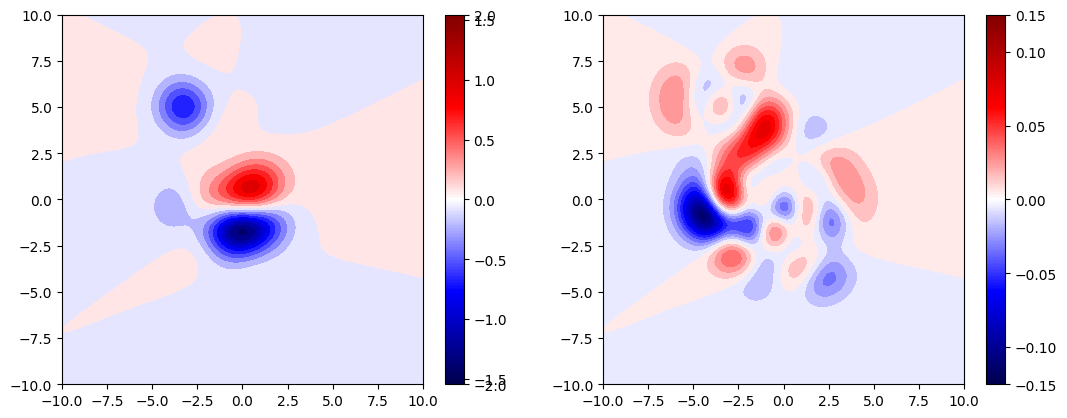

In [10]:
plt.close(fig)
print("gpytorch GPR using RBF kernel with loocv pseudo mll")


def loocv_pseudo_mll(
	x: torch.Tensor,
	y: torch.Tensor,
	model: gpytorch.models.ExactGP,
	likelihood: gpytorch.likelihoods.GaussianLikelihood
) -> torch.Tensor:
	return -gpytorch.mlls.LeaveOneOutPseudoLikelihood(likelihood, model)(model(x), y)


plot(gpytorch_gpr(x_t, y_t, gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(DIM)), loocv_pseudo_mll, x_test_t))

gpytorch GPR using RBF kernel with loocv squared error
Parameter name: cov.outputscale                            value = 0.6931471805599453
Parameter name: cov.base_kernel.lengthscale                value = [[0.69314718 0.69314718]]
Iter 0 - Loss: 308.6909716147359 - lr: 1.0
Parameter name: cov.raw_outputscale                        value = -1.0 grad = 0.6212022524259453
Parameter name: cov.base_kernel.raw_lengthscale            value = [[1. 1.]] grad = [[-29.08507218 -56.56956271]]
Parameter name: cov.outputscale                            value = 0.31326168751822286
Parameter name: cov.base_kernel.lengthscale                value = [[1.31326169 1.31326169]]
Convergence: |f_i - f_{i+1}| <= FTOL
Iter 62 - Loss: 9.46253088563364 - lr: 1.52587890625e-05
Parameter name: cov.outputscale                            value = 0.0031802933047039403
Parameter name: cov.base_kernel.lengthscale                value = [[1.10602042 0.96170994]]
Mean squared error = 0.0001246327881309165
Mean absolut

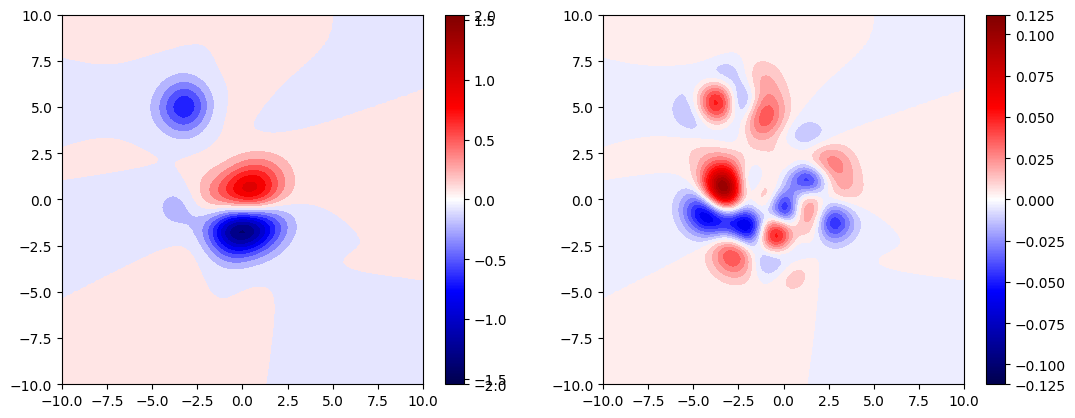

In [11]:
plt.close(fig)
print("gpytorch GPR using RBF kernel with loocv squared error")


def loocv_se(
	x: torch.Tensor,
	y: torch.Tensor,
	model: gpytorch.models.ExactGP,
	likelihood: gpytorch.likelihoods.GaussianLikelihood
) -> torch.Tensor:
	k_cho = torch.linalg.cholesky(likelihood(model(x)).covariance_matrix)
	return ((torch.cholesky_solve(y.reshape(-1, 1), k_cho) / torch.cholesky_inverse(k_cho).diag()) ** 2).sum()


plot(gpytorch_gpr(x_t, y_t, gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(DIM)), loocv_se, x_test_t))

gpytorch GPR using RBF kernel with loocv squared error with regularization
Parameter name: cov.outputscale                            value = 0.6931471805599453
Parameter name: cov.base_kernel.lengthscale                value = [[0.69314718 0.69314718]]
Iter 0 - Loss: 308.6929331942377 - lr: 1.0
Parameter name: cov.raw_outputscale                        value = -1.0 grad = 0.6206535545707781
Parameter name: cov.base_kernel.raw_lengthscale            value = [[1. 1.]] grad = [[-29.08545383 -56.56974781]]
Parameter name: cov.outputscale                            value = 0.31326168751822286
Parameter name: cov.base_kernel.lengthscale                value = [[1.31326169 1.31326169]]
Convergence: |f_i - f_{i+1}| <= FTOL
Iter 88 - Loss: 9.580053167096121 - lr: 1.52587890625e-05
Parameter name: cov.outputscale                            value = 0.0032993255792672896
Parameter name: cov.base_kernel.lengthscale                value = [[1.10469354 0.96208704]]
Mean squared error = 0.00012325877

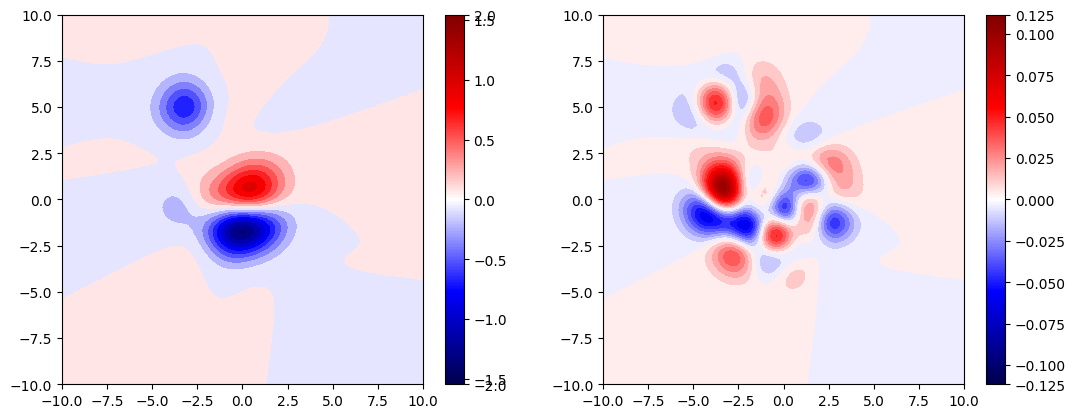

In [12]:
plt.close(fig)
print("gpytorch GPR using RBF kernel with loocv squared error with regularization")


def loocv_se_reg(
	x: torch.Tensor,
	y: torch.Tensor,
	model: gpytorch.models.ExactGP,
	likelihood: gpytorch.likelihoods.GaussianLikelihood
) -> torch.Tensor:
	k_cho: torch.Tensor = torch.linalg.cholesky(likelihood(model(x)).covariance_matrix)
	k_inv_y: torch.Tensor = torch.cholesky_solve(y.reshape(-1, 1), k_cho)
	return ((k_inv_y / torch.cholesky_inverse(k_cho).diag()) ** 2).sum() + NOISE * k_inv_y.T @ model(x).covariance_matrix @ k_inv_y


plot(gpytorch_gpr(x_t, y_t, gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(DIM)), loocv_se_reg, x_test_t))

gpytorch GPR using RBF kernel with exact mll and loocv pseudo mll
Parameter name: cov.outputscale                            value = 0.6931471805599453
Parameter name: cov.base_kernel.lengthscale                value = [[0.69314718 0.69314718]]
Iter 0 - Loss: 308.6909716147359 - lr: 1.0
Parameter name: cov.raw_outputscale                        value = -1.0 grad = 0.6212022524259453
Parameter name: cov.base_kernel.raw_lengthscale            value = [[1. 1.]] grad = [[-29.08507218 -56.56956271]]
Parameter name: cov.outputscale                            value = 0.31326168751822286
Parameter name: cov.base_kernel.lengthscale                value = [[1.31326169 1.31326169]]
Convergence: |f_i - f_{i+1}| <= FTOL
Iter 62 - Loss: 9.46253088563364 - lr: 1.52587890625e-05
Parameter name: cov.outputscale                            value = 0.0031802933047039403
Parameter name: cov.base_kernel.lengthscale                value = [[1.10602042 0.96170994]]
Mean squared error = 0.0001246327881309165
M

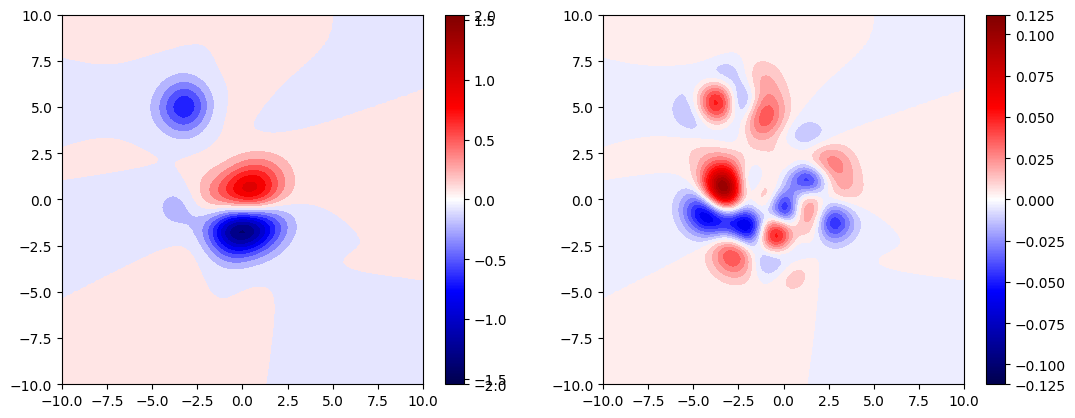

In [13]:
plt.close(fig)
print("gpytorch GPR using RBF kernel with exact mll and loocv pseudo mll")


def exact_and_loocv_mll(
	x: torch.Tensor,
	y: torch.Tensor,
	model: gpytorch.models.ExactGP,
	likelihood: gpytorch.likelihoods.GaussianLikelihood
) -> torch.Tensor:
	return exact_mll(x, y, model, likelihood) + loocv_pseudo_mll(x, y, model, likelihood)


plot(gpytorch_gpr(x_t, y_t, gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(DIM)), loocv_se, x_test_t))

gpytorch GPR using RBF kernel with pseudo inverse
Parameter name: cov.outputscale                            value = 0.6931471805599453
Parameter name: cov.base_kernel.lengthscale                value = [[0.69314718 0.69314718]]
Iter 0 - Loss: 0.08663351772543831 - lr: 1.0
Parameter name: cov.raw_outputscale                        value = 1.0 grad = -1.054548779772162e-15
Parameter name: cov.base_kernel.raw_lengthscale            value = [[1. 1.]] grad = [[-1.75174298 -2.11741876]]
Parameter name: cov.outputscale                            value = 1.3132616875182228
Parameter name: cov.base_kernel.lengthscale                value = [[1.31326169 1.31326169]]
Convergence: |f_i - f_{i+1}| <= FTOL
Iter 13 - Loss: 0.050912468879919896 - lr: 3.0517578125e-05
Parameter name: cov.outputscale                            value = 1.4459117539145563
Parameter name: cov.base_kernel.lengthscale                value = [[1.14928104 1.23356753]]
Mean squared error = 1.713869576964897e-05
Mean absolute e

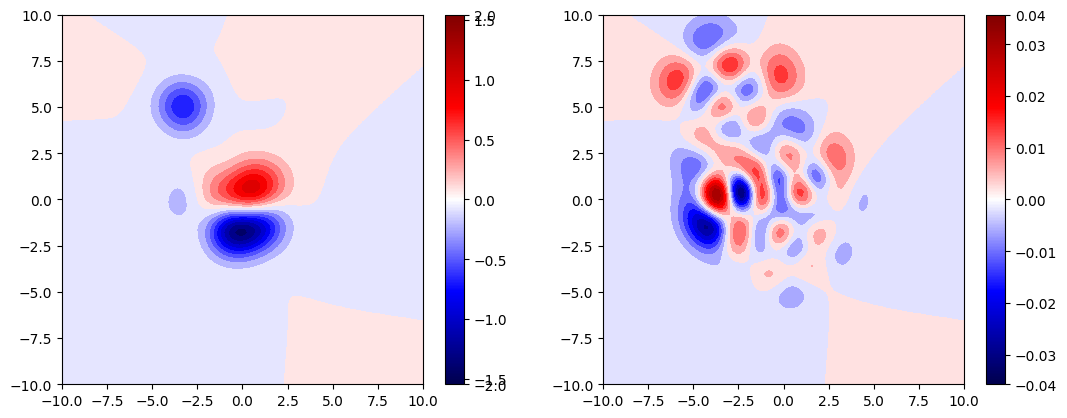

In [14]:
plt.close(fig)
print("gpytorch GPR using RBF kernel with pseudo inverse")


def mpi_pred(
	model: gpytorch.models.ExactGP,
	likelihood: gpytorch.likelihoods.GaussianLikelihood,
	x: torch.Tensor,
	x_test: torch.Tensor,
	x_all: torch.Tensor,
	y_all: torch.Tensor
) -> torch.Tensor:
	return model.cov(x_test, x) @ torch.linalg.pinv(model.cov(x_all, x).evaluate()) @ y_all


def approx_se(
	x: torch.Tensor,
	model: gpytorch.models.ExactGP,
	likelihood: gpytorch.likelihoods.GaussianLikelihood,
	x_all: torch.Tensor,
	y_all: torch.Tensor,
	pred: typing.Callable
) -> torch.Tensor:
	return ((y_all - pred(model, likelihood, x, x_all, x_all, y_all)) ** 2).sum()


def mp_inv_se(
	x: torch.Tensor,
	y: torch.Tensor,
	model: gpytorch.models.ExactGP,
	likelihood: gpytorch.likelihoods.GaussianLikelihood,
	x_all: torch.Tensor,
	y_all: torch.Tensor
) -> torch.Tensor:
	return approx_se(x, model, likelihood, x_all, y_all, mpi_pred)


plot(gpytorch_gpr(x_t, y_t, gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(DIM)), mp_inv_se, x_test_t, mpi_pred, x_all=x_all_t, y_all=y_all_t))

gpytorch GPR using RBF kernel and subset of regressors approximation with squared error
Parameter name: cov.outputscale                            value = 0.6931471805599453
Parameter name: cov.base_kernel.lengthscale                value = [[0.69314718 0.69314718]]
Iter 0 - Loss: 0.08663353760394457 - lr: 1.0
Parameter name: cov.raw_outputscale                        value = 1.0 grad = -6.798916837294153e-09
Parameter name: cov.base_kernel.raw_lengthscale            value = [[1. 1.]] grad = [[-1.75174298 -2.11741876]]
Parameter name: cov.outputscale                            value = 1.3132616875182228
Parameter name: cov.base_kernel.lengthscale                value = [[1.31326169 1.31326169]]
Convergence: |f_i - f_{i+1}| <= FTOL
Iter 13 - Loss: 0.05091247507600945 - lr: 7.62939453125e-06
Parameter name: cov.outputscale                            value = 1.5446038819064414
Parameter name: cov.base_kernel.lengthscale                value = [[1.14926541 1.23355131]]
Mean squared error =

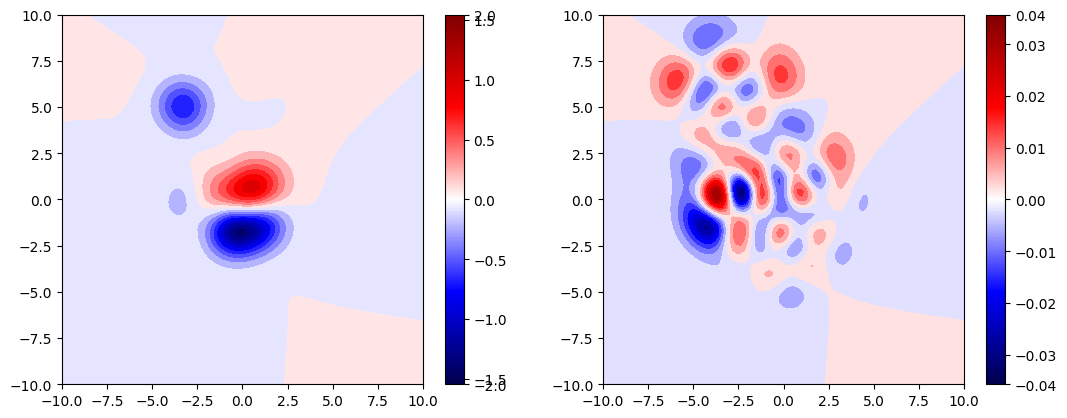

In [15]:
plt.close(fig)
print("gpytorch GPR using RBF kernel and subset of regressors approximation with squared error")


def sr_pred(
	model: gpytorch.models.ExactGP,
	likelihood: gpytorch.likelihoods.GaussianLikelihood,
	x: torch.Tensor,
	x_test: torch.Tensor,
	x_all: torch.Tensor,
	y_all: torch.Tensor
) -> torch.Tensor:
	noise: float = likelihood.noise[0].item()
	kmm: torch.Tensor = model.cov(x, x)
	kmn: torch.Tensor = model.cov(x, x_all)
	return model.cov(x_test, x) @ torch.cholesky_inverse(torch.linalg.cholesky((kmn @ kmn.T + noise * kmm).evaluate())) @ kmn @ y_all


def sr_se(
	x: torch.Tensor,
	y: torch.Tensor,
	model: gpytorch.models.ExactGP,
	likelihood: gpytorch.likelihoods.GaussianLikelihood,
	x_all: torch.Tensor,
	y_all: torch.Tensor
) -> torch.Tensor:
	return approx_se(x, model, likelihood, x_all, y_all, sr_pred)


plot(gpytorch_gpr(x_t, y_t, gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(DIM)), sr_se, x_test_t, sr_pred, x_all=x_all_t, y_all=y_all_t))

gpytorch GPR using RBF kernel and subset of regressors approximation with mll
Parameter name: cov.outputscale                            value = 0.6931471805599453
Parameter name: cov.base_kernel.lengthscale                value = [[0.69314718 0.69314718]]
Iter 0 - Loss: 47.51478038732719 - lr: 1.0
Parameter name: cov.raw_outputscale                        value = -1.0 grad = 36.136832339360154
Parameter name: cov.base_kernel.raw_lengthscale            value = [[-1.  1.]] grad = [[ 1.97917712 -1.99369855]]
Parameter name: cov.outputscale                            value = 0.31326168751822286
Parameter name: cov.base_kernel.lengthscale                value = [[0.31326169 1.31326169]]
Convergence: |f_i - f_{i+1}| <= FTOL
Iter 25 - Loss: -410.3916954642533 - lr: 0.00048828125
Parameter name: cov.outputscale                            value = 3.0007071015062784e-05
Parameter name: cov.base_kernel.lengthscale                value = [[1.31754861 0.87800741]]
Mean squared error = 0.0002196895

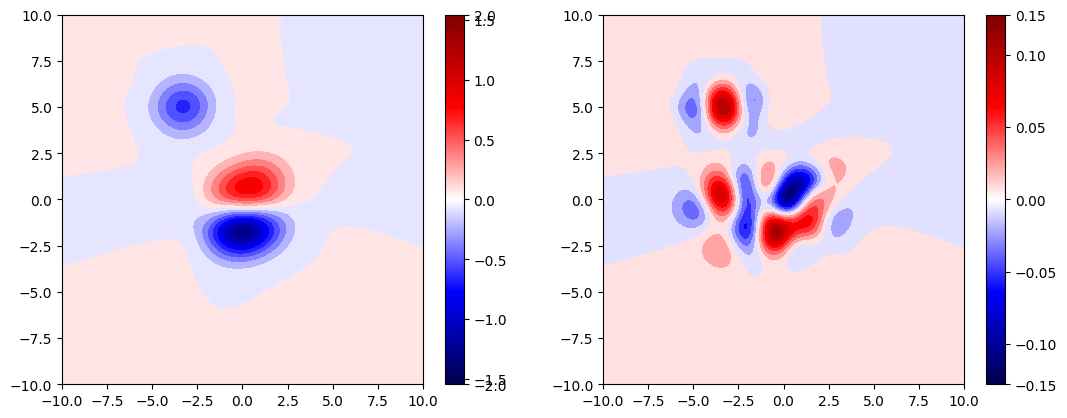

In [16]:
plt.close(fig)
print("gpytorch GPR using RBF kernel and subset of regressors approximation with mll")


def sr_mll(
	x: torch.Tensor,
	y: torch.Tensor,
	model: gpytorch.models.ExactGP,
	likelihood: gpytorch.likelihoods.GaussianLikelihood,
	x_all: torch.Tensor,
	y_all: torch.Tensor
) -> torch.Tensor:
	noise: float = likelihood.noise[0].item()
	m: int = x.shape[-2]
	n: int = x_all.shape[-2]
	kmm: torch.Tensor = model.cov(x, x).evaluate() + noise * torch.eye(m)
	kmn: torch.Tensor = model.cov(x, x_all)
	Sigma: torch.Tensor = (kmn @ kmn.T + noise * kmm).evaluate()
	return torch.logdet(Sigma) - torch.logdet(kmm) + (y_all.reshape(1, -1) @ (torch.eye(n) - kmn.T @ torch.cholesky_inverse(torch.linalg.cholesky(Sigma)) @ kmn) @ y_all.reshape(-1, 1)).reshape(1)


plot(gpytorch_gpr(x_t, y_t, gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(DIM)), sr_mll, x_test_t, sr_pred, x_all=x_all_t, y_all=y_all_t))

gpytorch GPR using RBF kernel and fully independent training conditional approximation with squared error
Parameter name: cov.outputscale                            value = 0.6931471805599453
Parameter name: cov.base_kernel.lengthscale                value = [[0.69314718 0.69314718]]
Iter 0 - Loss: 0.5428376948495077 - lr: 1.0
Parameter name: cov.raw_outputscale                        value = -1.0 grad = 0.023821037603184436
Parameter name: cov.base_kernel.raw_lengthscale            value = [[1. 1.]] grad = [[-3.2935751  -3.57072136]]
Parameter name: cov.outputscale                            value = 0.31326168751822286
Parameter name: cov.base_kernel.lengthscale                value = [[1.31326169 1.31326169]]
Convergence: |f_i - f_{i+1}| <= FTOL
Iter 447 - Loss: 0.10900949699438432 - lr: 0.00048828125
Parameter name: cov.outputscale                            value = 0.014122314348449998
Parameter name: cov.base_kernel.lengthscale                value = [[1.04039067 1.12364745]]
Mean

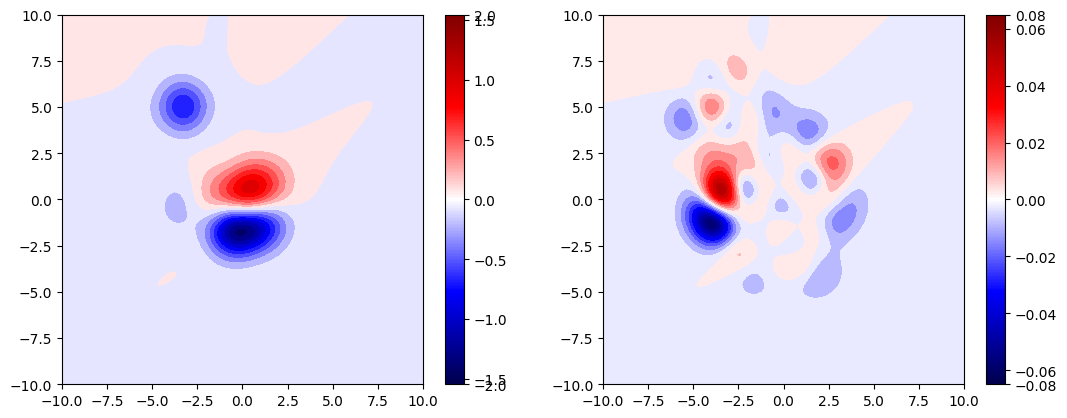

In [17]:
plt.close(fig)
print("gpytorch GPR using RBF kernel and fully independent training conditional approximation with squared error")


def fitc_pred(
	model: gpytorch.models.ExactGP,
	likelihood: gpytorch.likelihoods.GaussianLikelihood,
	x: torch.Tensor,
	x_test: torch.Tensor,
	x_all: torch.Tensor,
	y_all: torch.Tensor
) -> npt.NDArray[np.double]:
	noise: float = likelihood.noise[0].item()
	m: int = x.shape[-2]
	n: int = x_all.shape[-2]
	kmm: torch.Tensor = (model.cov(x, x) + noise * torch.eye(m)).evaluate()
	kmn: torch.Tensor = model.cov(x, x_all)
	Lambda: torch.Tensor = model.cov(x_all, x_all, True) - (kmn.T @ torch.cholesky_inverse(torch.linalg.cholesky(kmm)) @ kmn).diag() + torch.full((n,), noise)
	Sigma: torch.Tensor = kmm + kmn @ (1.0 / Lambda).diag() @ kmn.T
	return model.cov(x_test, x) @ torch.cholesky_inverse(torch.linalg.cholesky(Sigma)) @ kmn @ (1.0 / Lambda).diag() @ y_all


def fitc_se(
	x: torch.Tensor,
	y: torch.Tensor,
	model: gpytorch.models.ExactGP,
	likelihood: gpytorch.likelihoods.GaussianLikelihood,
	x_all: torch.Tensor,
	y_all: torch.Tensor
) -> torch.Tensor:
	return approx_se(x, model, likelihood, x_all, y_all, fitc_pred)


plot(gpytorch_gpr(x_t, y_t, gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(DIM)), fitc_se, x_test_t, fitc_pred, x_all=x_all_t, y_all=y_all_t))

Parameter name: cov.outputscale                            value = 0.6931471805599453
Parameter name: cov.base_kernel.lengthscale                value = [[0.69314718 0.69314718]]
Iter 0 - Loss: 2.8511023786654413 - lr: 1.0
Parameter name: cov.raw_outputscale                        value = 1.0 grad = -5.424060354197735e-06
Parameter name: cov.base_kernel.raw_lengthscale            value = [[ 1. -1.]] grad = [[-4.36678207 12.28376317]]
Parameter name: cov.outputscale                            value = 1.3132616875182228
Parameter name: cov.base_kernel.lengthscale                value = [[1.31326169 0.31326169]]
Convergence: |f_i - f_{i+1}| <= FTOL
Iter 17 - Loss: 0.0509124709777482 - lr: 3.0517578125e-05
Parameter name: cov.outputscale                            value = 2.9140876103128357
Parameter name: cov.base_kernel.lengthscale                value = [[0.59220647 0.39835528]]
Mean squared error = 1.7138409935537875e-05
Mean absolute error = 0.00192317052072144
Maximum error = 0.03248

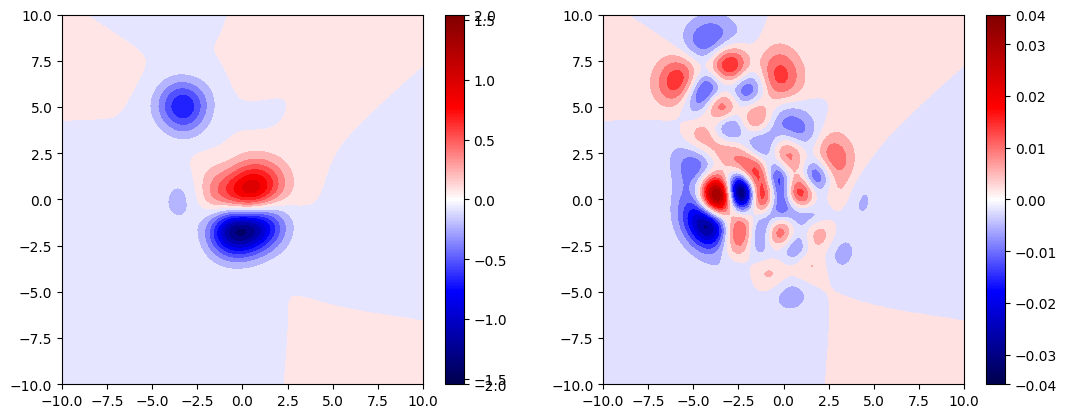

In [18]:
def normalize(x: torch.Tensor, x_ref: torch.Tensor | None = None) -> torch.Tensor:
	if x_ref is None:
		x_ref = x
	return (x - torch.mean(x_ref, 0)) / torch.std(x_ref, 0)


def unnormalize(x_norm: torch.Tensor, x_ref: torch.Tensor) -> torch.Tensor:
	return x_norm * torch.std(x_ref, 0) + torch.mean(x_ref, 0)


plot(gpytorch_gpr(normalize(x_t), y_t, gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(DIM)), sr_se, normalize(x_test_t, x_t), sr_pred, x_all=normalize(x_all_t, x_t), y_all=y_all_t))

In [19]:
def lengthscale_error(x: torch.Tensor, y: torch.Tensor, x_test: torch.Tensor, y_test: torch.Tensor, min: float = 0.1, max: float = 2.1) -> tuple[npt.NDArray[np.double], npt.NDArray[np.double], npt.NDArray[np.double], npt.NDArray[np.double]]:
	def pred_given_lengthscale(x: torch.Tensor, y: torch.Tensor, length: torch.Tensor, x_test: torch.Tensor) -> npt.NDArray[np.double]:
		likelihood: gpytorch.likelihoods.FixedNoiseGaussianLikelihood = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(torch.full((x.shape[0],), NOISE))
		model: MyGPR = MyGPR(x, y, likelihood, gpytorch.kernels.RBFKernel(DIM))
		model.eval()
		model.cov.lengthscale = length
		likelihood.eval()
		return likelihood(model(x_test), noise=torch.full((x_test.shape[0],), NOISE)).mean.detach().numpy().reshape(N_GRIDS, N_GRIDS)

	xv: npt.NDArray[np.double]
	pv: npt.NDArray[np.double]
	xv, pv = np.meshgrid(np.linspace(min, max, N_GRIDS), np.linspace(min, max, N_GRIDS))
	lengths: npt.NDArray[np.double] = np.concatenate((xv[:, :, np.newaxis], pv[:, :, np.newaxis]), axis=-1)
	values: npt.NDArray[np.double] = np.zeros((3, N_GRIDS, N_GRIDS))
	for i in range(N_GRIDS):
		for j in range(N_GRIDS):
			diff: npt.NDArray[np.double] = pred_given_lengthscale(x, y, lengths[i, j], x_test) - y_test.detach().numpy()
			values[0, i, j] = np.average(diff ** 2)
			values[1, i, j] = np.average(np.abs(diff))
			values[2, i, j] = np.max(np.abs(diff))
	return xv, pv, lengths, values


xv, pv, lengths, errors = lengthscale_error(x_t, y_t, x_test_t, y_test_t)


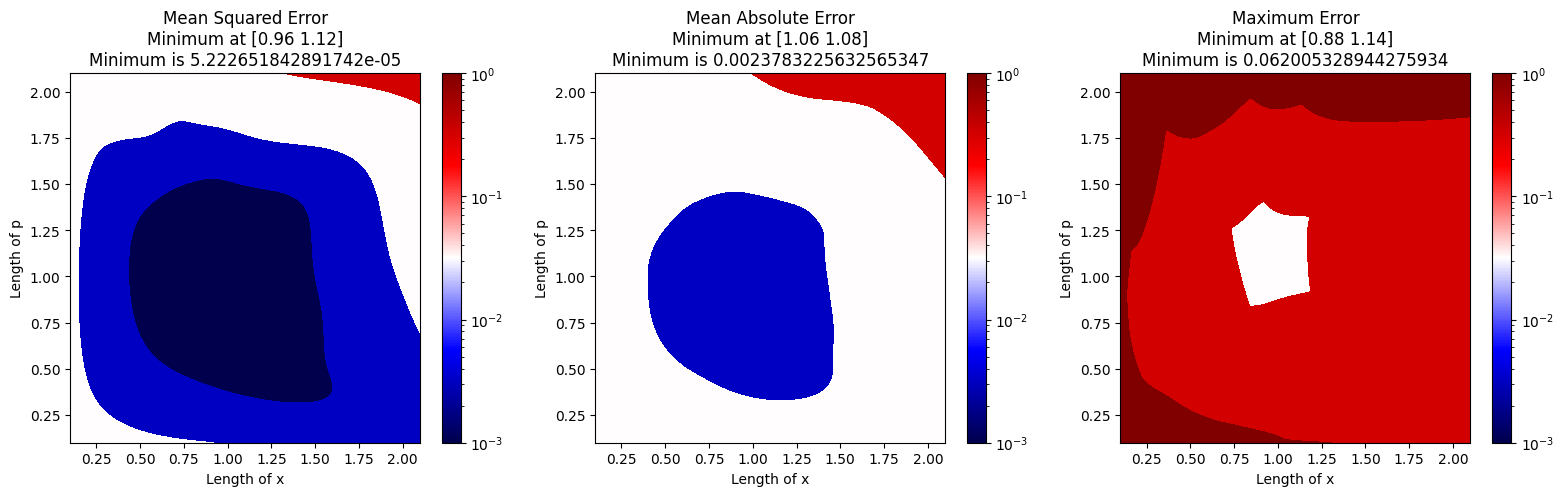

In [20]:
plt.close(fig)
fig: matplotlib.figure.Figure
axs: np.ndarray[collections.abc.Sequence[matplotlib.axes.Axes], np.dtype[np.object_]]
fig, axs = plt.subplots(1, 3, figsize=(FIGSIZE[0] * 3, FIGSIZE[1]))
norm: matplotlib.colors.LogNorm = matplotlib.colors.LogNorm(np.power(10.0, int(np.log10(np.min(errors))) + 1), np.power(10.0, int(np.log10(np.max(errors)))))
titles: list[str] = ['Mean Squared Error', 'Mean Absolute Error', 'Maximum Error']
for i in range(3):
	ax: matplotlib.axes.Axes = axs[i]
	ax.contourf(xv, pv, errors[i], cmap=CMAP, norm=norm)
	argmin_ind = np.unravel_index(np.argmin(errors[i]), errors[i].shape)
	ax.set_title(titles[i] + '\nMinimum at {}'.format(lengths[argmin_ind]) + '\nMinimum is {}'.format(errors[i][argmin_ind]))
	ax.set_xlabel('Length of x')
	ax.set_ylabel('Length of p')
	fig.colorbar(matplotlib.cm.ScalarMappable(cmap=CMAP, norm=norm), ax=ax)